# Exploratory Data Analysis (EDA) – Mushroom Classification

This notebook performs exploratory data analysis and preprocessing on the Mushroom Dataset from the UCI Machine Learning Repository. The dataset contains physical characteristics of mushrooms that can be used to classify them as edible or poisonous.

The goal of this analysis is to better understand the dataset before applying machine learning models. The dataset consists of 8,124 mushroom samples described by 22 categorical features, such as cap shape, odor, gill characteristics, stalk properties, and habitat. The target variable indicates whether a mushroom is edible or poisonous.

In this notebook, we perform the following steps:

1. Load and inspect the dataset
2. Examine the dataset structure and categorical features
3. Analyze the class distribution
4. Identify and handle missing values in the stalk-root feature
5. Explore feature distributions through basic visualizations
6. Apply preprocessing steps including categorical encoding
7. Split the dataset into training and testing sets for later model training

These preprocessing steps prepare the dataset for the machine learning models that will be implemented in later stages of the project, including Decision Tree, Random Forest, and Naive Bayes classifiers.

In [1]:
# Load Libraries
import pandas as pd
import numpy as np

In [2]:
# Define Dataset Columns
columns = [
'class','cap-shape','cap-surface','cap-color','bruises','odor',
'gill-attachment','gill-spacing','gill-size','gill-color',
'stalk-shape','stalk-root','stalk-surface-above-ring',
'stalk-surface-below-ring','stalk-color-above-ring',
'stalk-color-below-ring','veil-type','veil-color',
'ring-number','ring-type','spore-print-color',
'population','habitat'
]

# Load Dataset
df = pd.read_csv("../Sources/data/mushrooms.csv", header=None, names=columns)
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [3]:
# Dataset Overview
df.shape

(8124, 23)

In [4]:
# Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

In [5]:
# Class Distribution
df['class'].value_counts()

class
e    4208
p    3916
Name: count, dtype: int64

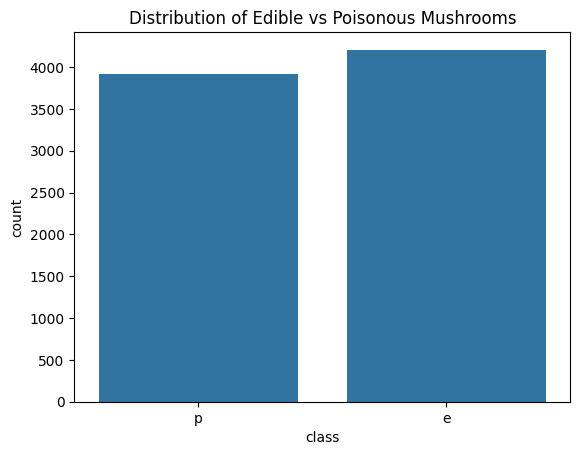

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='class', data=df)
plt.title("Distribution of Edible vs Poisonous Mushrooms")
plt.show()

In [7]:
# Missing Values
(df == '?').sum()

class                          0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64

In [8]:
# Handling Missing Values
# The `stalk-root` feature contains missing values represented by "?". We will replace these with a new category called "missing".
df['stalk-root'].replace('?', 'missing', inplace=True)
(df =='?').sum()


/var/folders/5p/wj1l79m94jvg506738kw6v4h0000gn/T/ipykernel_3202/653787153.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['stalk-root'].replace('?', 'missing', inplace=True)


class                          0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64

In [9]:
# Unique Values per Feature
for col in df.columns:
    print(col, df[col].unique())

class <ArrowStringArray>
['p', 'e']
Length: 2, dtype: str
cap-shape <ArrowStringArray>
['x', 'b', 's', 'f', 'k', 'c']
Length: 6, dtype: str
cap-surface <ArrowStringArray>
['s', 'y', 'f', 'g']
Length: 4, dtype: str
cap-color <ArrowStringArray>
['n', 'y', 'w', 'g', 'e', 'p', 'b', 'u', 'c', 'r']
Length: 10, dtype: str
bruises <ArrowStringArray>
['t', 'f']
Length: 2, dtype: str
odor <ArrowStringArray>
['p', 'a', 'l', 'n', 'f', 'c', 'y', 's', 'm']
Length: 9, dtype: str
gill-attachment <ArrowStringArray>
['f', 'a']
Length: 2, dtype: str
gill-spacing <ArrowStringArray>
['c', 'w']
Length: 2, dtype: str
gill-size <ArrowStringArray>
['n', 'b']
Length: 2, dtype: str
gill-color <ArrowStringArray>
['k', 'n', 'g', 'p', 'w', 'h', 'u', 'e', 'b', 'r', 'y', 'o']
Length: 12, dtype: str
stalk-shape <ArrowStringArray>
['e', 't']
Length: 2, dtype: str
stalk-root <ArrowStringArray>
['e', 'c', 'b', 'r', '?']
Length: 5, dtype: str
stalk-surface-above-ring <ArrowStringArray>
['s', 'f', 'k', 'y']
Length: 4, dtyp

In [10]:
# Drop veil-type as it has only one unique value
df.drop(columns=['veil-type'], inplace=True)

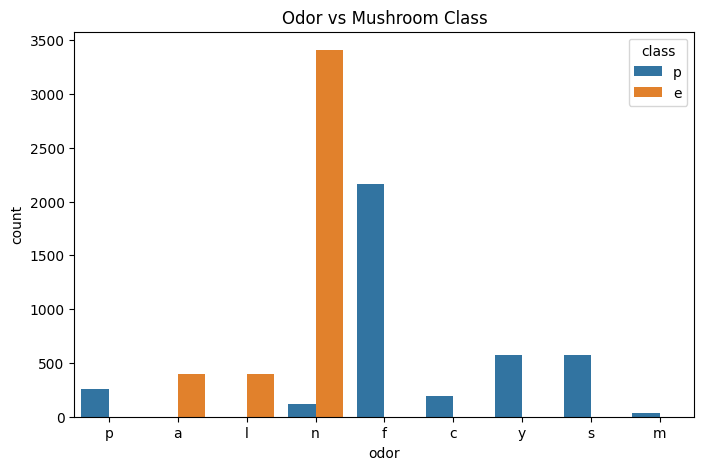

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(x='odor', hue='class', data=df)
plt.title("Odor vs Mushroom Class")
plt.show()

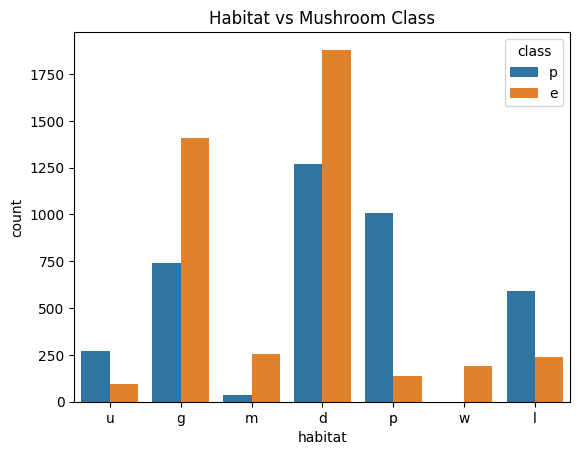

In [12]:
sns.countplot(x='habitat', hue='class', data=df)
plt.title("Habitat vs Mushroom Class")
plt.show()

In [13]:
# Encoding Categorical Features
from sklearn.preprocessing import LabelEncoder

label_encoders = {}  # store one encoder per column
for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # save each one

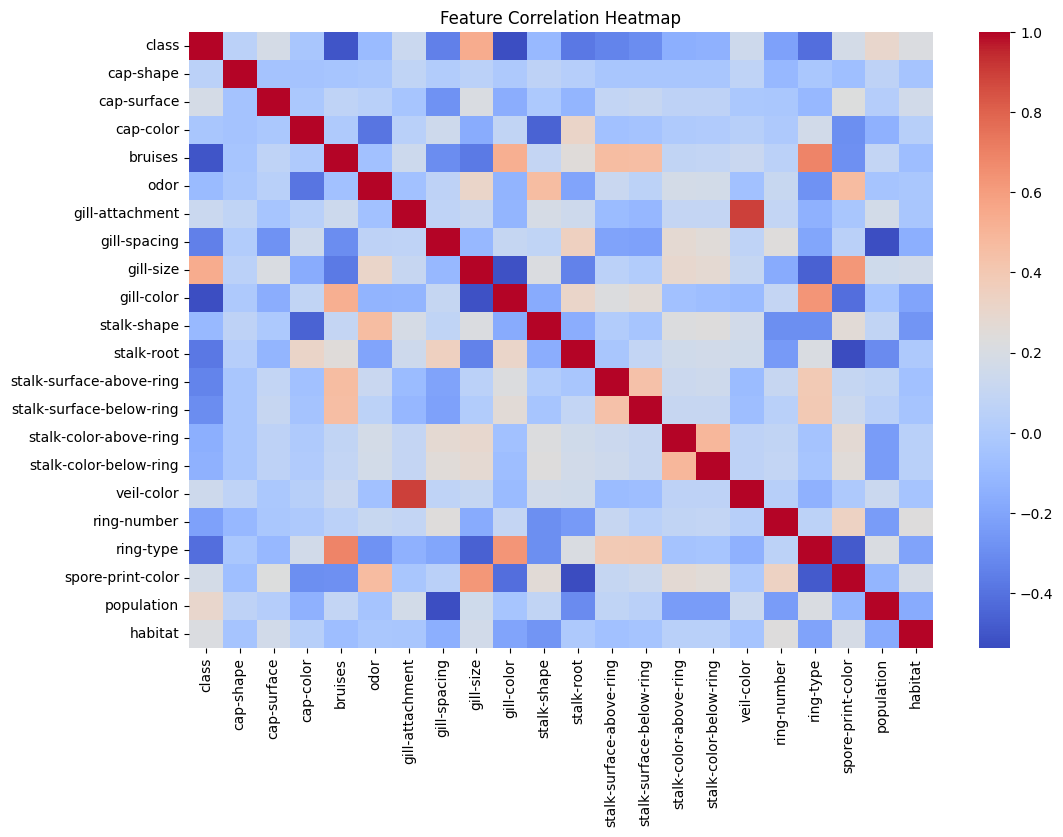

In [14]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [15]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X = df.drop('class', axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [16]:
print(X_train.shape)
print(X_test.shape)

(6499, 21)
(1625, 21)


In [17]:
# Save Processed Dataset
df.to_csv("../Sources/data/processed_mushrooms.csv", index=False)

## Preprocessing Summary

The dataset was preprocessed before model training.

Steps performed:

1. Examined the dataset structure and categorical features.
2. Analyzed missing values in the stalk-root feature.
3. Replaced missing values ("?") with a new category called "missing".
4. Removed the constant feature `veil-type`, which contained only one unique value.
5. Encoded categorical variables using Label Encoding.
6. Split the dataset into training and testing sets using an 80/20 split.
7. Saved the processed dataset for model training.